In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/terremotos_chile.csv")
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-11-04T13:14:08.494Z,-36.9223,-73.8084,10.000,4.4,mb,58.0,105.0,2.250,0.55,...,2025-11-04T15:48:21.040Z,"56 km NW of Arauco, Chile",earthquake,8.12,1.882,0.086,46.0,reviewed,us,us
1,2025-11-03T21:22:01.175Z,-22.0898,-68.5445,117.842,4.3,mb,25.0,47.0,0.710,0.59,...,2025-11-03T21:41:26.040Z,"56 km NE of Calama, Chile",earthquake,5.42,7.032,0.201,7.0,reviewed,us,us
2,2025-11-03T15:51:54.565Z,-27.4457,-71.4784,24.928,5.5,mww,71.0,96.0,0.634,0.72,...,2025-11-04T16:19:32.037Z,"113 km W of Copiapó, Chile",earthquake,3.95,4.582,0.073,18.0,reviewed,us,us
3,2025-11-02T18:51:46.506Z,-36.9168,-73.9572,10.000,4.7,mb,44.0,123.0,2.351,0.80,...,2025-11-02T19:44:50.758Z,"67 km WNW of Arauco, Chile",earthquake,6.34,1.877,0.110,25.0,reviewed,us,us
4,2025-11-02T13:16:34.641Z,-19.0317,-69.9459,79.280,4.7,mb,34.0,139.0,0.757,0.73,...,2025-11-02T13:45:17.040Z,"28 km ENE of Cuya, Chile",earthquake,3.33,5.100,0.123,20.0,reviewed,us,us


In [7]:
df.shape

(15982, 22)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15982 entries, 0 to 15981
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             15982 non-null  object 
 1   latitude         15982 non-null  float64
 2   longitude        15982 non-null  float64
 3   depth            15982 non-null  float64
 4   mag              15982 non-null  float64
 5   magType          15982 non-null  object 
 6   nst              6883 non-null   float64
 7   gap              14861 non-null  float64
 8   dmin             11046 non-null  float64
 9   rms              14630 non-null  float64
 10  net              15982 non-null  object 
 11  id               15982 non-null  object 
 12  updated          15982 non-null  object 
 13  place            15971 non-null  object 
 14  type             15982 non-null  object 
 15  horizontalError  10734 non-null  float64
 16  depthError       13294 non-null  float64
 17  magError    

In [9]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,15982.000000,15982.000000,15982.000000,15982.000000,6883.000000,14861.000000,11046.000000,14630.000000,10734.000000,13294.000000,10975.000000,13831.000000
mean,-27.848926,-70.300417,81.954919,4.431485,51.199477,104.357042,0.956922,0.873456,6.056938,6.516106,0.167528,22.759887
std,6.404828,2.225166,68.930892,0.417109,63.562962,46.502256,0.669192,0.281201,2.130627,4.582328,0.106000,36.973770
min,-54.813700,-75.991500,0.600000,3.000000,4.000000,11.800000,0.004000,0.000000,0.000000,0.000000,0.022000,1.000000
25%,-33.197075,-71.984000,25.372500,4.200000,19.000000,66.000000,0.459000,0.680000,4.600000,4.000000,0.071000,5.000000
50%,-27.977500,-70.658100,49.500000,4.400000,30.000000,100.000000,0.776000,0.850000,5.700000,5.600000,0.159000,10.000000
75%,-21.926650,-68.607050,122.798000,4.600000,53.000000,142.000000,1.384000,1.040000,7.330000,7.800000,0.232000,27.000000
max,-17.506400,-66.006400,310.490000,8.800000,681.000000,314.400000,10.422000,3.880000,18.300000,72.800000,0.556000,663.000000


In [11]:
df.select_dtypes(include='object').columns

Index(['time', 'magType', 'net', 'id', 'updated', 'place', 'type', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [13]:
df['time'] = pd.to_datetime(df['time'])
df['time'].dt.year.value_counts().sort_index()

time
2010    2265
2011     676
2012     556
2013     618
2014    1395
2015    1718
2016    1010
2017    1034
2018     760
2019     769
2020     937
2021     908
2022     883
2023     910
2024     857
2025     686
Name: count, dtype: int64

In [14]:
df.isna().sum().sort_values(ascending=False)

nst                9099
horizontalError    5248
magError           5007
dmin               4936
depthError         2688
magNst             2151
rms                1352
gap                1121
place                11
mag                   0
latitude              0
time                  0
depth                 0
longitude             0
magType               0
updated               0
net                   0
id                    0
type                  0
status                0
locationSource        0
magSource             0
dtype: int64

In [19]:
cols_relevantes = ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place']
df = df[cols_relevantes].dropna()

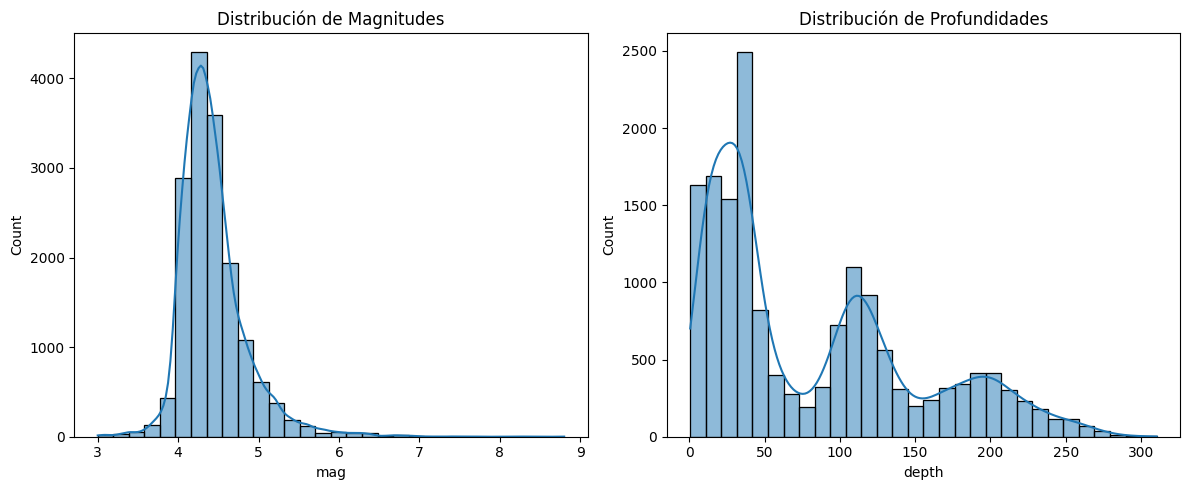

In [ ]:
df.isna().sum()

In [21]:
df.describe()

,latitude,longitude,depth,mag
count,15971.000000,15971.000000,15971.000000,15971.000000
mean,-27.852483,-70.302042,81.903350,4.431426
std,6.404907,2.224854,68.918217,0.417167
min,-54.813700,-75.991500,0.600000,3.000000
25%,-33.199500,-71.984700,25.350000,4.200000
50%,-27.981500,-70.661200,49.400000,4.400000
75%,-21.927850,-68.608400,122.695000,4.600000
max,-17.506400,-66.006400,310.490000,8.800000


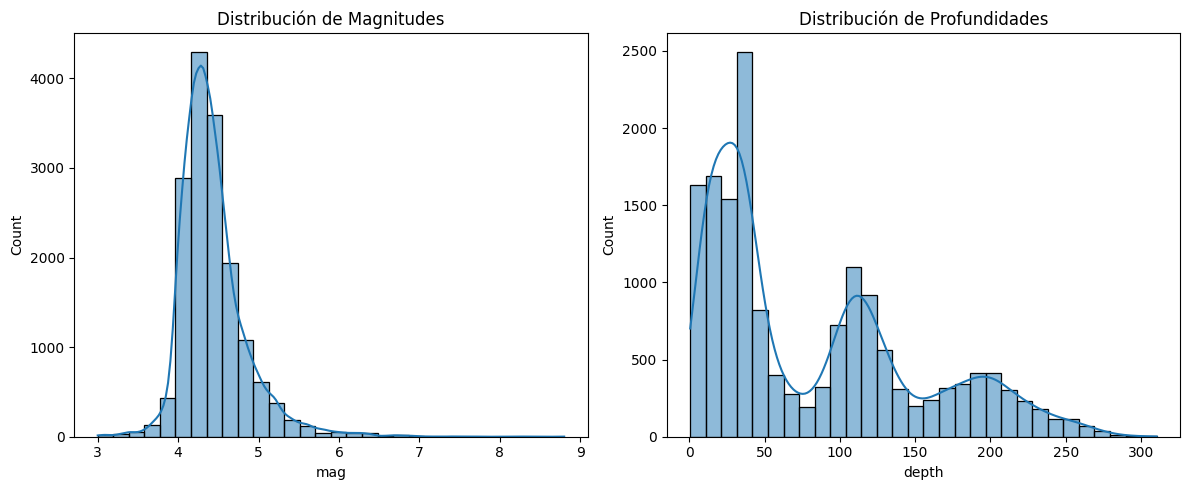

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['mag'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Magnitudes')

sns.histplot(df['depth'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribución de Profundidades')

plt.tight_layout()
plt.show()